### Classification prediction model training

In [1]:
import pandas as pd 
import numpy as np 

In [2]:
file_path = "survey_lung_cancer.csv"
df = pd.read_csv(file_path)

In [3]:
print("shape: ",df.shape)
print("Printing 5 rows in dataset")

df.head()

shape:  (309, 16)
Printing 5 rows in dataset


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [5]:
df.dtypes


GENDER                   object
AGE                       int64
SMOKING                   int64
YELLOW_FINGERS            int64
ANXIETY                   int64
PEER_PRESSURE             int64
CHRONIC DISEASE           int64
FATIGUE                   int64
ALLERGY                   int64
WHEEZING                  int64
ALCOHOL CONSUMING         int64
COUGHING                  int64
SHORTNESS OF BREATH       int64
SWALLOWING DIFFICULTY     int64
CHEST PAIN                int64
LUNG_CANCER              object
dtype: object

In [14]:
df.isnull().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [ ]:
from sklearn.preprocessing import LabelEncoder

X = df.iloc[:,:-1].copy()
y = df.iloc[:,-1].copy()

print("Target column name : ",df.columns[-1])
print("Target column unique values: ")
print(y.astype(str).unique())

Target column name :  LUNG_CANCER
Target column unique values: 
['YES' 'NO']


In [25]:
# cleaning columns name

X.columns = X.columns.str.strip()

# identify categorical and numerical columns

categorical_columns = X.select_dtypes(include = ['object']).columns

print("Categorical columns :",categorical_columns)

Categorical columns : Index(['GENDER'], dtype='object')


In [26]:
# encode the categorical columns
encoder = {}

for col in categorical_columns:
    X[col] = X[col].astype(str).str.strip().str.lower()

    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

    # save
    encoder[col]= le

X.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1


In [30]:
# split the model into training and testing 

from sklearn.model_selection import train_test_split

X_test, X_train, y_test, y_train = train_test_split(X,y, train_size = 0.2, random_state=42)

print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (248, 15)
X_test shape:  (61, 15)
y_train shape:  (248,)
y_test shape:  (61,)


In [34]:
# feature scaling

# z = (x-mean)/SD

from sklearn.preprocessing import StandardScaler

binary_column = ["GENDER"]

numeric_columns = [col for col in X.columns if col not in binary_column]

scaler = StandardScaler()

X[numeric_columns] = scaler.fit_transform(X[numeric_columns])

X.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
0,1,0.771850,-1.135292,0.869300,1.003241,-1.003241,-1.009756,0.696833,-1.120480,0.892475,0.892475,0.852207,0.748736,1.063501,0.892475
1,1,1.381829,0.880830,-1.150351,-0.996769,-1.003241,0.990338,0.696833,0.892475,-1.120480,-1.120480,-1.173424,0.748736,1.063501,0.892475
2,0,-0.448107,-1.135292,-1.150351,-0.996769,0.996769,-1.009756,0.696833,-1.120480,0.892475,-1.120480,0.852207,0.748736,-0.940291,0.892475
3,1,0.039876,0.880830,0.869300,1.003241,-1.003241,-1.009756,-1.435063,-1.120480,-1.120480,0.892475,-1.173424,-1.335584,1.063501,0.892475
4,0,0.039876,-1.135292,0.869300,-0.996769,-1.003241,-1.009756,-1.435063,-1.120480,0.892475,-1.120480,0.852207,0.748736,-0.940291,-1.120480


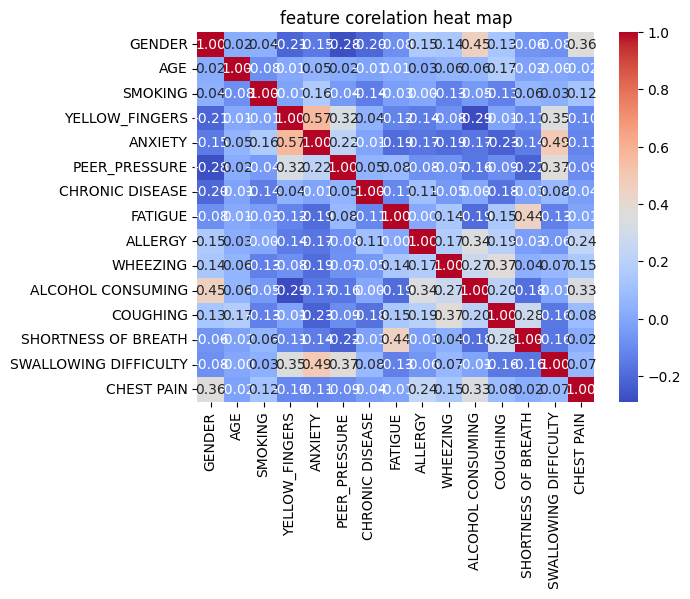

In [38]:
# visualization 

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("feature corelation heat map")
plt.show()



In [42]:
# training the model

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier( n_estimators=200, max_depth= None,min_samples_split=2, min_samples_leaf=1,random_state=42)

model.fit(X_train,y_train)

print("model training successful")

model training successful


In [47]:
# evaluating the model

from sklearn.metrics import confusion_matrix, recall_score, f1_score, accuracy_score, classification_report

# predict

y_pred = model.predict(X_test)

# evaluation

accuracy = accuracy_score(y_pred, y_test)
print("accuracy score = ", accuracy)

cm = confusion_matrix(y_pred, y_test)
print("confusion matrix = ", cm)

report = classification_report(y_pred, y_test)
print(report)



accuracy score =  0.8852459016393442
confusion matrix =  [[ 3  4]
 [ 3 51]]
              precision    recall  f1-score   support

          NO       0.50      0.43      0.46         7
         YES       0.93      0.94      0.94        54

    accuracy                           0.89        61
   macro avg       0.71      0.69      0.70        61
weighted avg       0.88      0.89      0.88        61



#### confusion matrix
- 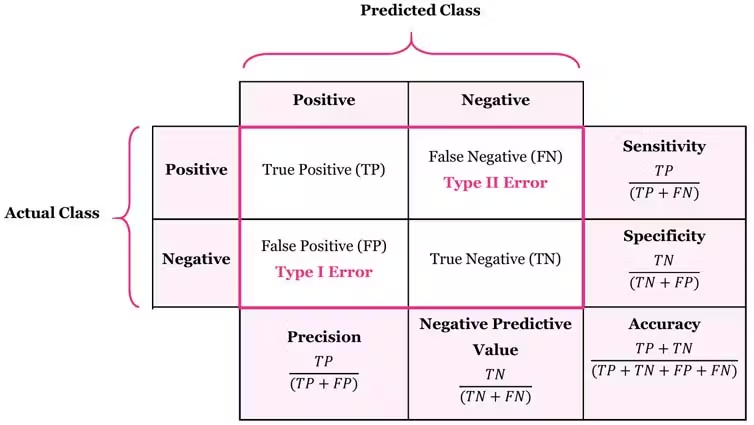
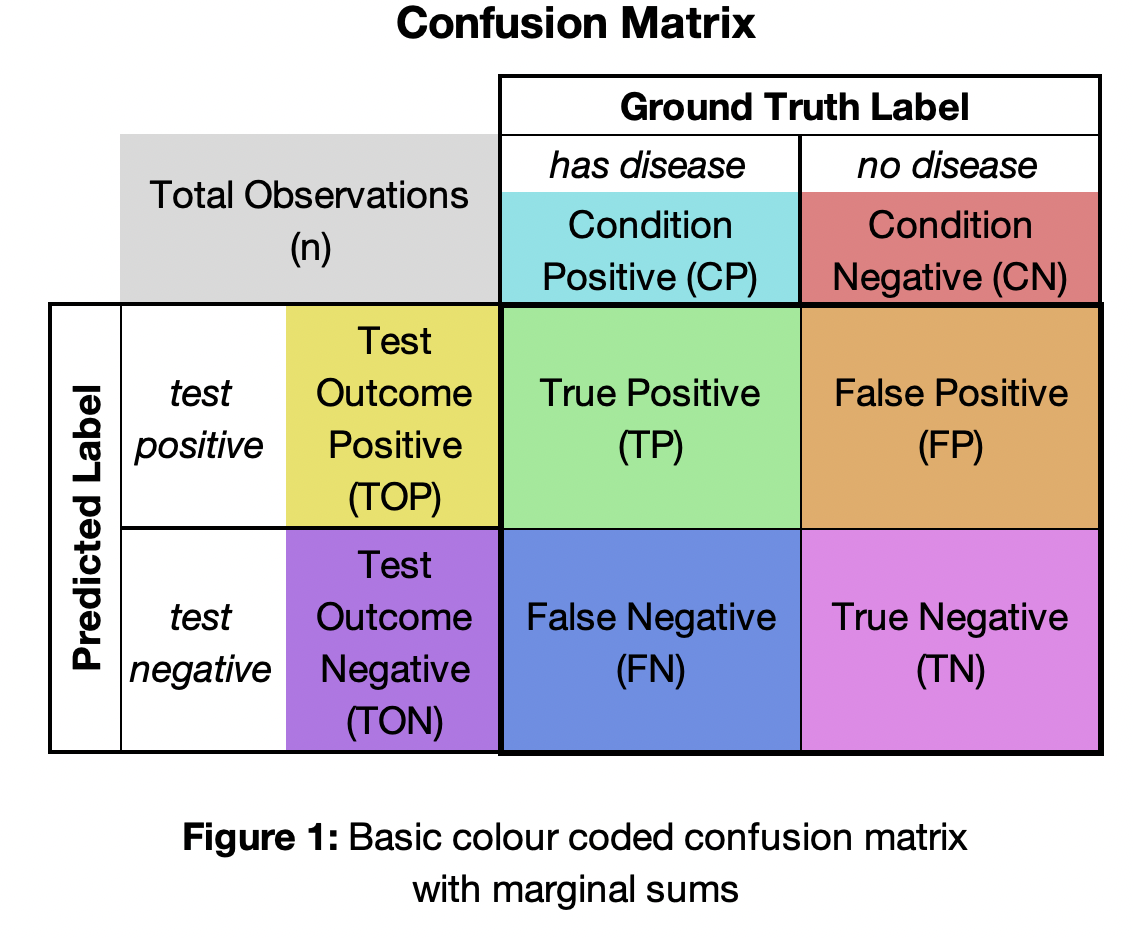

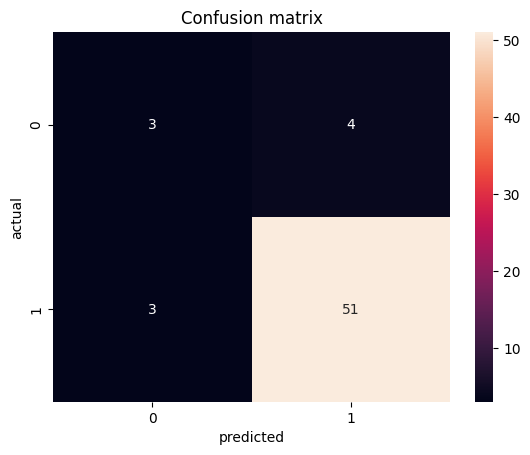

In [49]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("Confusion matrix")
plt.show()

In [52]:
# feature importance
feature_importance = pd.DataFrame({
    "Features": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=True)

print(feature_importance)

                 Features  Importance
12    SHORTNESS OF BREATH    0.031355
2                 SMOKING    0.039565
0                  GENDER    0.039686
14             CHEST PAIN    0.042540
9                WHEEZING    0.045365
7                 FATIGUE    0.048319
6         CHRONIC DISEASE    0.048915
4                 ANXIETY    0.049277
11               COUGHING    0.057794
3          YELLOW_FINGERS    0.061477
5           PEER_PRESSURE    0.064176
13  SWALLOWING DIFFICULTY    0.069421
10      ALCOHOL CONSUMING    0.086116
8                 ALLERGY    0.097522
1                     AGE    0.218474


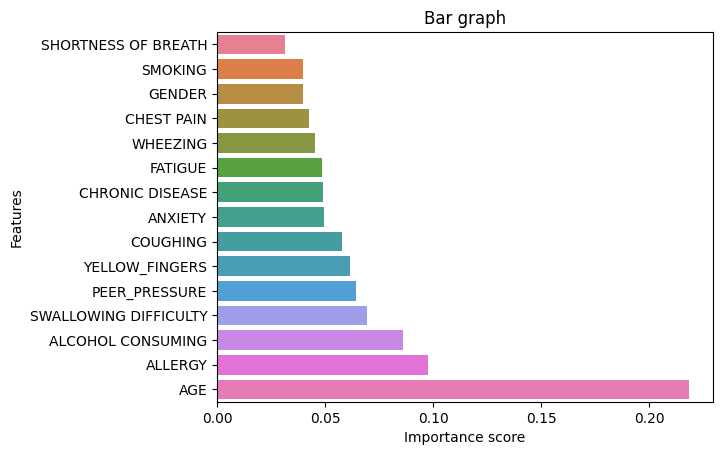

In [54]:
# bar chart

plt.figure()
sns.barplot(data= feature_importance, x = 'Importance', y = "Features", hue = "Features", legend=False)
plt.xlabel("Importance score")
plt.ylabel("Features")
plt.title("Bar graph")
plt.show()

In [55]:
import joblib

artifacts = {
    "model" : model,
    "scaler" : scaler,
    "label_encoder" : le,
    "features_name": X.columns.tolist()
}

joblib.dump(artifacts, "lung_cancer.pkl")

print("model saved as lung_cancer.pkl")

model saved as lung_cancer.pkl
